Intra-model Comparison for WIND with metrics score 

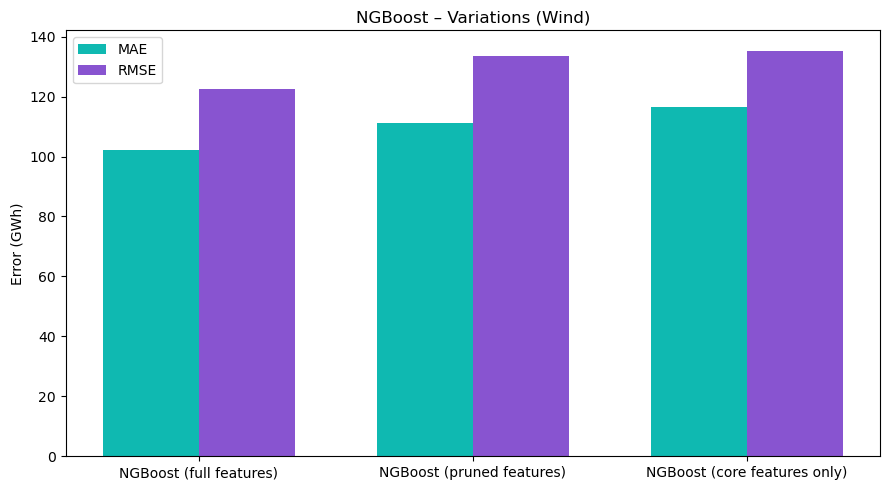

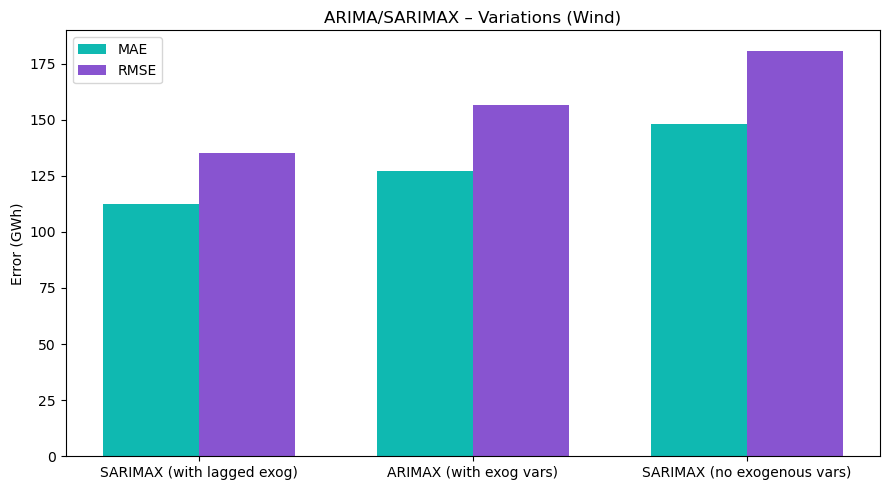

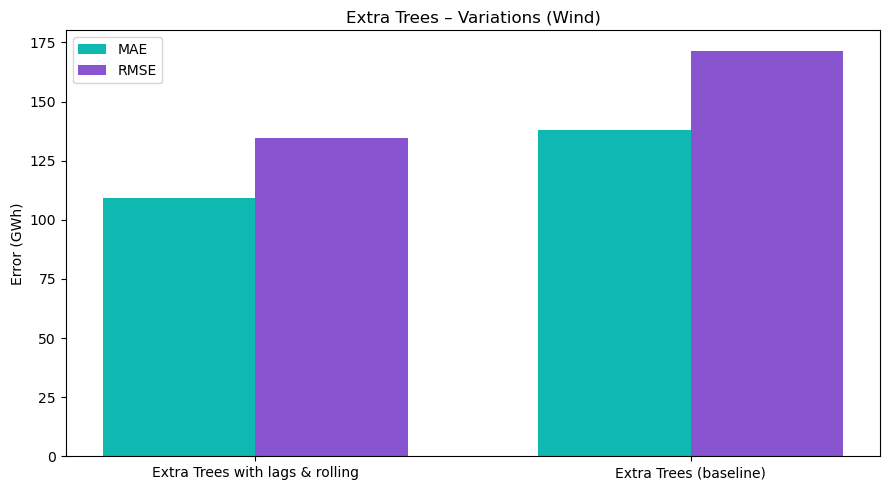

Step 1 complete.
Family plots saved:
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\NGBoost_Wind_variations.png
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\ARIMA_SARIMAX_Wind_variations.png
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Extra_Trees_Wind_variations.png
Winners table: C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Wind_GWh_step1_winners.csv


,model_name,display_name,family,target,mae,rmse,r2_score,ci_coverage_pct,mean_ci_width,model_size_mb,training_time_sec,inference_time_per_sample_sec,dataset_used,notes
0,NGBoost_Wind,NGBoost (full features),NGBoost,Wind_GWh,102.06,122.51,0.789,NaN,NaN,1.81,108.65,0.064581,Final_Wind_Data_Model,Bayesian tuning with 25 iterations
1,SARIMAX_lagged_exog,SARIMAX (with lagged exog),ARIMA/SARIMAX,Wind_GWh,112.23,135.36,0.723,NaN,NaN,22.43,1.21,0.006913,Final_Wind_Data_Model,"order=(2, 1, 2), seasonal_order=(0, 1, 1, 12);..."
2,ExtraTreesRegressor,Extra Trees with lags & rolling,Extra Trees,Wind_GWh,109.23,134.73,0.745,NaN,NaN,7.81,6.22,0.042095,Final_Wind_Data_Model.csv,Trained on lag and rolling mean features (chro...


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


LOG_CSV = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\model_logs.csv"

# NGBoost CI coverage files fo wind
CI_FILES = {
    "NGBoost_Wind": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_with_CI.csv",
    "NGBoost_Wind_Pruned_features": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_CI_Coverage.csv",
    "NGBoost_wind_core_features": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_core_feature_CI_coverage.csv",
}

# save 
OUT_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot"
os.makedirs(OUT_DIR, exist_ok=True)

# Naming & Families

NAME_MAP = {
    "NGBoost_Wind": "NGBoost (full features)",
    "NGBoost_Wind_Pruned_features": "NGBoost (pruned features)",
    "NGBoost_wind_core_features": "NGBoost (core features only)",
    "ExtraTreesRegressor": "Extra Trees with lags & rolling",
    "ExtraTrees_Wind_Baseline": "Extra Trees (baseline)",
    "SARIMAX_no_exog": "SARIMAX (no exogenous vars)",
    "SARIMAX_lagged_exog": "SARIMAX (with lagged exog)",
    "ARIMAX_exog": "ARIMAX (with exog vars)",
}

def get_family(name: str) -> str:
    if name.startswith("NGBoost"):
        return "NGBoost"
    if name.startswith("ExtraTrees"):
        return "Extra Trees"
    if name.startswith("SARIMAX") or name.startswith("ARIMAX"):
        return "ARIMA/SARIMAX"
    return name.split("_")[0]

# Helpers
# Return dict with coverage_pct and mean_ci_width if CSV exists and columns are recognizable.
# Accepts columns like: Actual, Lower90, Upper90 
def try_compute_ci_metrics(ci_path: str):

    if not ci_path or not os.path.exists(ci_path):
        return {"ci_coverage_pct": np.nan, "mean_ci_width": np.nan}

    df = pd.read_csv(ci_path)
    cols = {c.lower(): c for c in df.columns}

    actual_col = cols.get("actual") or cols.get("y") or cols.get("y_true")
    low_col = cols.get("lower90") or cols.get("lower") or cols.get("y_lower") or cols.get("lower_bound")
    up_col  = cols.get("upper90") or cols.get("upper") or cols.get("y_upper") or cols.get("upper_bound")

    if not (actual_col and low_col and up_col):
        return {"ci_coverage_pct": np.nan, "mean_ci_width": np.nan}

    a = pd.to_numeric(df[actual_col], errors="coerce")
    l = pd.to_numeric(df[low_col], errors="coerce")
    u = pd.to_numeric(df[up_col], errors="coerce")

    mask = a.notna() & l.notna() & u.notna()
    a, l, u = a[mask], l[mask], u[mask]
    if len(a) == 0:
        return {"ci_coverage_pct": np.nan, "mean_ci_width": np.nan}

    coverage = ((a >= l) & (a <= u)).mean() * 100.0
    mean_width = (u - l).mean()
    return {"ci_coverage_pct": float(coverage), "mean_ci_width": float(mean_width)}

def within_1pct(x, ref):
    if pd.isna(x) or pd.isna(ref) or ref == 0:
        return False
    return abs(x - ref) <= 0.01 * ref

def plot_family_bars(group_df: pd.DataFrame, family: str, out_dir: str):
    """
    Grouped bars: MAE (teal), RMSE (purple). X = variations.
    """
    g = group_df.sort_values("mae").copy()
    x = np.arange(len(g))
    w = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - w/2, g["mae"], width=w, label="MAE", color="#0fb9b1")     # teal
    plt.bar(x + w/2, g["rmse"], width=w, label="RMSE", color="#8854d0")   # purple
    plt.xticks(x, g["display_name"], rotation=0, ha="center")
    plt.ylabel("Error (GWh)")
    plt.title(f"{family} – Variations (Wind)")
    plt.legend()
    plt.tight_layout()

    # Sanitize family name for safe file path
    safe_family = family.replace("/", "_").replace("\\", "_").replace(" ", "_")
    fname = os.path.join(out_dir, f"{safe_family}_Wind_variations.png")

    plt.savefig(fname, dpi=300)
    plt.show()
    plt.close()
    return fname



# Load & Filter WIND data
logs = pd.read_csv(LOG_CSV)
# Keep Wind only
wind = logs[logs["target"] == "Wind_GWh"].copy()

# Ensure numeric
for c in ["mae", "rmse", "r2_score", "model_size_mb", "training_time_sec"]:
    if c in wind.columns:
        wind[c] = pd.to_numeric(wind[c], errors="coerce")

# Attach family and  pretty names
wind["family"] = wind["model_name"].apply(get_family)
wind["display_name"] = wind["model_name"].map(NAME_MAP).fillna(wind["model_name"])

# Attach CI only for NGBoost rows
wind["ci_coverage_pct"] = np.nan
wind["mean_ci_width"] = np.nan
for i, row in wind.iterrows():
    name = row["model_name"]
    if name.startswith("NGBoost"):
        ci_path = CI_FILES.get(name, None)
        metrics = try_compute_ci_metrics(ci_path)
        wind.at[i, "ci_coverage_pct"] = metrics["ci_coverage_pct"]
        wind.at[i, "mean_ci_width"] = metrics["mean_ci_width"]


# Select Step-1 Winners

winners = []
plot_paths = []

for fam, grp in wind.groupby("family", sort=False):
    # Family plot
    plot_path = plot_family_bars(grp, fam, OUT_DIR)
    plot_paths.append(plot_path)

    # Option A selection with 1% rule
    g = grp.sort_values(["mae", "rmse"], ascending=[True, True]).copy()

    mae_min = g["mae"].min()
    g = g[g["mae"].apply(lambda x: within_1pct(x, mae_min))]

    rmse_min = g["rmse"].min()
    g = g[g["rmse"].apply(lambda x: within_1pct(x, rmse_min))]

    # If NGBoost family and CI available prefer higher CI coverage
    if fam == "NGBoost" and g["ci_coverage_pct"].notna().any():
        g = g.sort_values(["ci_coverage_pct"], ascending=[False])

    # Otherwise prefer smaller model, then shorter training time
    if "model_size_mb" in g.columns:
        g = g.sort_values(["model_size_mb"], ascending=[True])
    if "training_time_sec" in g.columns:
        g = g.sort_values(["training_time_sec"], ascending=[True])

    winners.append(g.iloc[0])

winners_df = pd.DataFrame(winners).reset_index(drop=True)

# Tidy columns for dissertation table
keep_cols = [
    "model_name", "display_name", "family", "target",
    "mae", "rmse", "r2_score",
    "ci_coverage_pct", "mean_ci_width",
    "model_size_mb", "training_time_sec", "inference_time_per_sample_sec",
    "dataset_used", "notes"
]
winners_df = winners_df[[c for c in keep_cols if c in winners_df.columns]]

# Save outputs
winners_csv = os.path.join(OUT_DIR, "Wind_GWh_step1_winners.csv")
winners_df.to_csv(winners_csv, index=False)

print("Step 1 complete.")
print("Family plots saved:")
for p in plot_paths:
    print(" -", p)
print("Winners table:", winners_csv)

# Display winners
winners_df


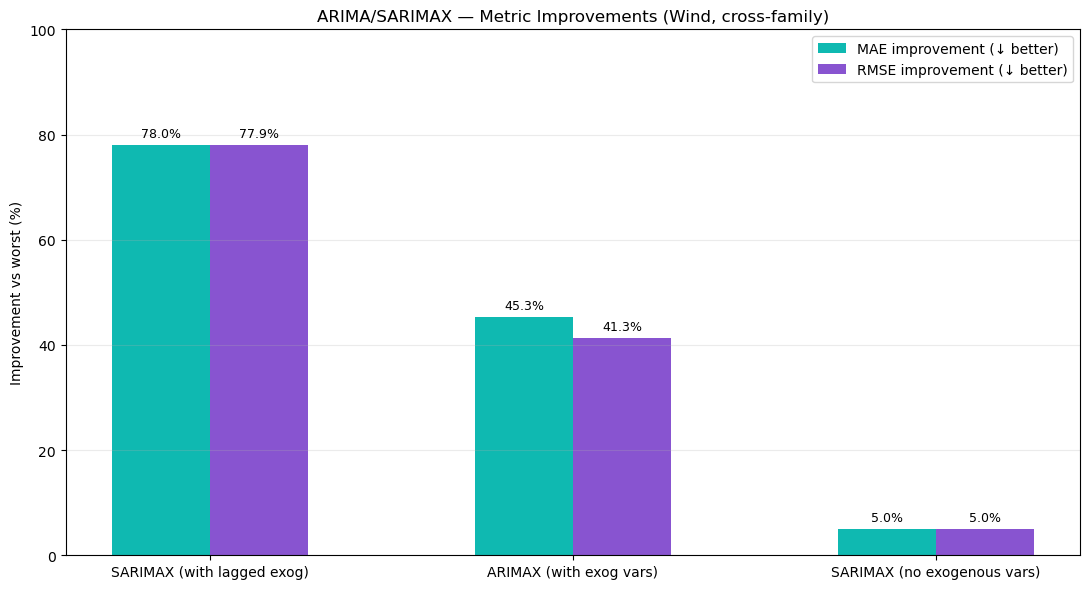

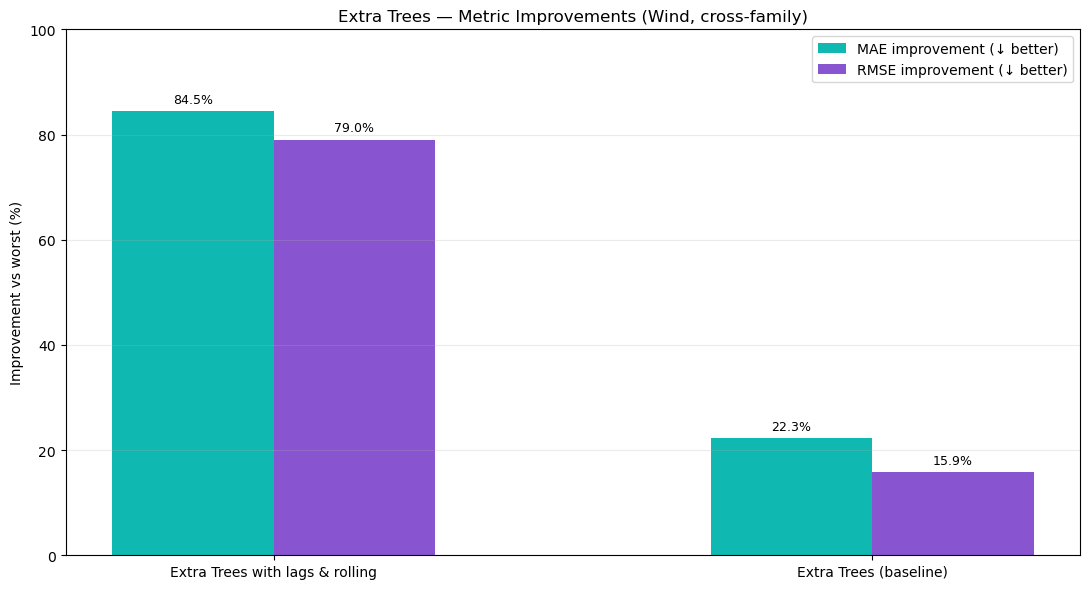

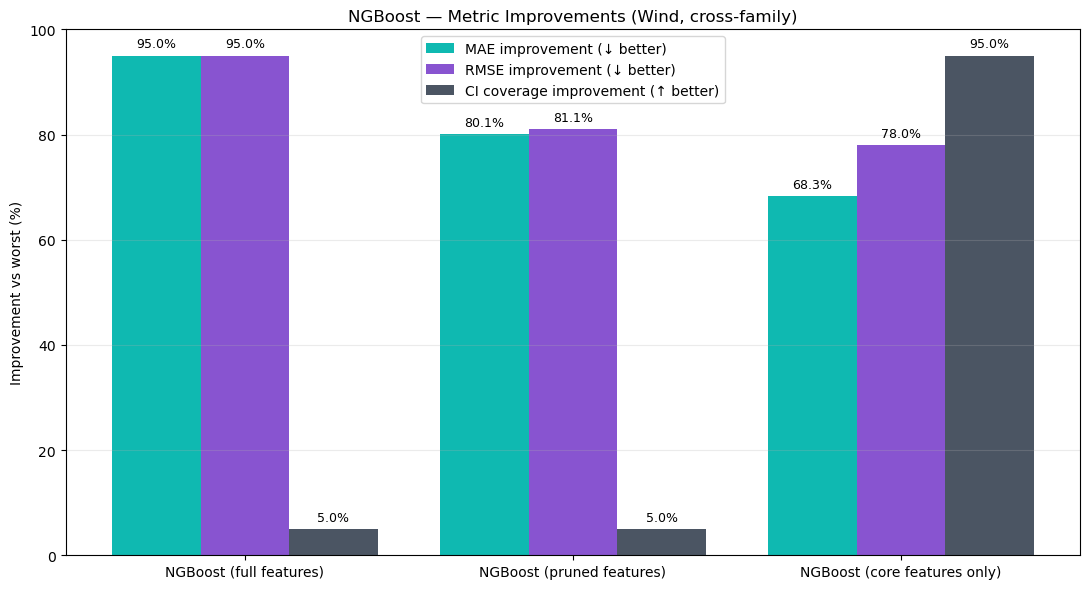

Saved:
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B\ARIMA_SARIMAX_Wind_optionB_improvement_crossfamily_FIXED_1.png
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B\Extra_Trees_Wind_optionB_improvement_crossfamily_FIXED_1.png
 - C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B\NGBoost_Wind_optionB_improvement_crossfamily_FIXED_1.png


In [ ]:
# === Wind  Option B — FIXED NGBoost CI BAR and percentage difference


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
SCORES_CSV = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B\Wind_Step1_OptionB_scores.csv"
OUT_DIR    = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAE  = "#0fb9b1"   # teal
C_RMSE = "#8854d0"   # purple
C_CI   = "#4b5563"   # dark gray

# Family/name helpers
NAME_MAP = {
    "NGBoost_Wind": "NGBoost (full features)",
    "NGBoost_Wind_Pruned_features": "NGBoost (pruned features)",
    "NGBoost_wind_core_features": "NGBoost (core features only)",
    "ExtraTreesRegressor": "Extra Trees with lags & rolling",
    "ExtraTrees_Wind_Baseline": "Extra Trees (baseline)",
    "SARIMAX_no_exog": "SARIMAX (no exogenous vars)",
    "SARIMAX_lagged_exog": "SARIMAX (with lagged exog)",
    "ARIMAX_exog": "ARIMAX (with exog vars)",
}

def family_of(name: str) -> str:
    if name.startswith("NGBoost"):
        return "NGBoost"
    if name.startswith("ExtraTrees"):
        return "Extra Trees"
    if name.startswith("SARIMAX") or name.startswith("ARIMAX"):
        return "ARIMA/SARIMAX"
    return name.split("_")[0]

# Improvement functions (cross-family
def imp_lower_is_better(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return pd.Series(np.nan, index=s.index)
    smax, smin = s.max(), s.min()
    if np.isclose(smax, smin):
        return pd.Series(100.0, index=s.index)
    return (smax - s) / (smax - smin) * 100.0

def imp_higher_is_better(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return pd.Series(np.nan, index=s.index)
    smax, smin = s.max(), s.min()
    if np.isclose(smax, smin):
        return pd.Series(100.0, index=s.index)
    return (s - smin) / (smax - smin) * 100.0

def clamp_5_95(s):
    return s.clip(lower=5.0, upper=95.0)

#  Load scores & prepare
df = pd.read_csv(SCORES_CSV)

# OPTION A: ALWAYS rebuild display_name from NAME_MAP (override any existing column)
existing = df["display_name"] if "display_name" in df.columns else None
df["display_name"] = (
    df["model_name"].map(NAME_MAP)
    .fillna(existing if existing is not None else df["model_name"])
)

# ensure family present
if "family" not in df.columns:
    df["family"] = df["model_name"].apply(family_of)

# Compute cross-family improvements from raw metrics if available, else from score_* as fallback
if "mae" in df.columns and df["mae"].notna().any():
    df["imp_mae"] = imp_lower_is_better(df["mae"])
elif "score_mae" in df.columns:
    df["imp_mae"] = imp_higher_is_better(df["score_mae"])

if "rmse" in df.columns and df["rmse"].notna().any():
    df["imp_rmse"] = imp_lower_is_better(df["rmse"])
elif "score_rmse" in df.columns:
    df["imp_rmse"] = imp_higher_is_better(df["score_rmse"])

# CI coverage (higher is better)
if "ci_coverage_pct" in df.columns and df["ci_coverage_pct"].notna().any():
    df["imp_ci"] = imp_higher_is_better(df["ci_coverage_pct"])
elif "score_ci" in df.columns:
    df["imp_ci"] = imp_higher_is_better(df["score_ci"])
else:
    df["imp_ci"] = np.nan

# Clamp for pretty labels
for c in ["imp_mae", "imp_rmse", "imp_ci"]:
    if c in df.columns:
        df[c] = clamp_5_95(df[c])

# Force a CI bar for all NGBoost variants: fill missing CI with floor (5%) 
is_ngb = df["family"] == "NGBoost"
df.loc[is_ngb & df["imp_ci"].isna(), "imp_ci"] = 5.0

# Plot per family (no overall, no merging) 
def plot_family(g, family, out_dir):
    g = g.copy()
    # sort by MAE improvement desc
    if g["imp_mae"].notna().any():
        g = g.sort_values("imp_mae", ascending=False)

    labels = g["display_name"].tolist()
    x = np.arange(len(labels))
    width = 0.27

    # metrics to show
    metric_cols = ["imp_mae", "imp_rmse"]
    metric_labels = ["MAE improvement (↓ better)", "RMSE improvement (↓ better)"]
    metric_colors = [C_MAE, C_RMSE]

    if family == "NGBoost":
        metric_cols.append("imp_ci")
        metric_labels.append("CI coverage improvement (↑ better)")
        metric_colors.append(C_CI)

    # offsets for 2 or 3 bars
    offsets = [-width/2, width/2] if len(metric_cols) == 2 else [-width, 0.0, width]

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, (col, lab, colr) in enumerate(zip(metric_cols, metric_labels, metric_colors)):
        vals = g[col].values
        bars = ax.bar(x + offsets[i], vals, width, label=lab, color=colr)
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + 1.0,
                f"{h:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_ylim(0, 100)
    ax.set_ylabel("Improvement vs worst (%)")
    ax.set_title(f"{family} — Metric Improvements (Wind, cross‑family)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha="center")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()

    safe_family = family.replace("/", "_").replace("\\", "_").replace(" ", "_")
    out_path = os.path.join(out_dir, f"{safe_family}_Wind_optionB_improvement_crossfamily_FIXED_1.png")
    fig.savefig(out_path, dpi=300)
    plt.show()
    plt.close(fig)
    return out_path

paths = []
for fam, grp in df.groupby("family"):
    paths.append(plot_family(grp, fam, OUT_DIR))

print("Saved:")
for p in paths:
    print(" -", p)
      

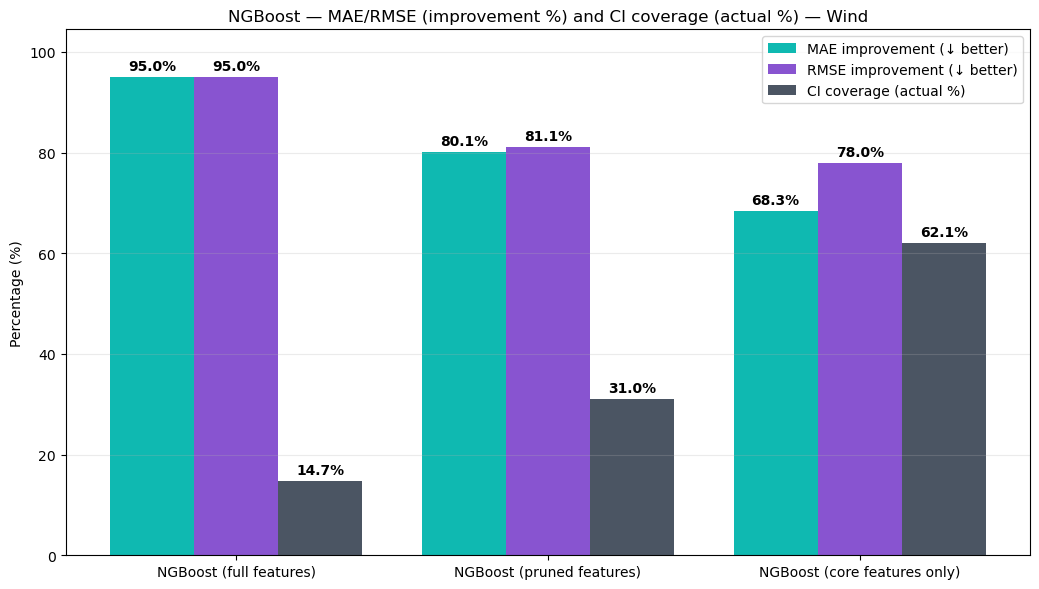

CI coverage used (actual %):
 - NGBoost (full features): 14.71% (full uses CALIBRATED)
 - NGBoost (pruned features): 31.03% (full uses CALIBRATED)
 - NGBoost (core features only): 62.07% (full uses CALIBRATED)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
IMPROV_CSV = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\wind\option_B\Wind_Step1_OptionB_improvements_crossfamily.csv"

CI_FILES = {
    "NGBoost_Wind_raw":        r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_with_CI.csv",
    "NGBoost_Wind_calibrated": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_with_CI_CALIBRATED.csv",
    "NGBoost_Wind_Pruned_features": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_CI_Coverage.csv",
    "NGBoost_wind_core_features": r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_core_feature_CI_coverage.csv",
}

# Use calibrated coverage for the full-features model
USE_CALIBRATED_FOR_FULL = True


C_MAE  = "#0fb9b1"  
C_RMSE = "#8854d0"   
C_CI   = "#4b5563"   

#  Name mapping
NAME_MAP = {
    "NGBoost_Wind": "NGBoost (full features)",
    "NGBoost_Wind_Pruned_features": "NGBoost (pruned features)",
    "NGBoost_wind_core_features": "NGBoost (core features only)",
}

# Helpers
def read_ci_coverage(path, actual_col=None, lower_col=None, upper_col=None):
    """Compute CI coverage % as share of Actual within [Lower, Upper]."""
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    actual  = actual_col or cols.get("actual") or cols.get("y") or cols.get("y_true")
    lower   = lower_col  or cols.get("lower90") or cols.get("lower_90") or cols.get("lower") or cols.get("y_lower") or cols.get("lower_bound")
    upper   = upper_col  or cols.get("upper90") or cols.get("upper_90") or cols.get("upper") or cols.get("y_upper") or cols.get("upper_bound")
    if not (actual and lower and upper):
        return np.nan
    a = pd.to_numeric(df[actual], errors="coerce")
    l = pd.to_numeric(df[lower], errors="coerce")
    u = pd.to_numeric(df[upper], errors="coerce")
    m = a.notna() & l.notna() & u.notna()
    if m.sum() == 0:
        return np.nan
    return float(((a[m] >= l[m]) & (a[m] <= u[m])).mean() * 100.0)

def annotate_bars(ax, bars):
    """Bold labels with staggered offsets to avoid overlap."""
    last_x = None
    for b in bars:
        h = b.get_height()
        x = b.get_x() + b.get_width()/2
        dy = 1.5 if (last_x is not None and abs(x - last_x) < 1e-6) else 0.8
        ax.text(x, h + dy, f"{h:.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="black")
        last_x = x

# Load improvement data 
imp = pd.read_csv(IMPROV_CSV)
imp.columns = [c.strip().lower() for c in imp.columns]

# Select NGBoost rows
ngb = imp[imp["family"].str.contains("ngboost", case=False, na=False)].copy()

# Apply pretty name mapping regardless of what's in CSV
ngb["display_name"] = ngb["model_name"].map(NAME_MAP).fillna(ngb["model_name"])

# Compute ACTUAL CI coverage %
ci_full = read_ci_coverage(CI_FILES["NGBoost_Wind_calibrated" if USE_CALIBRATED_FOR_FULL else "NGBoost_Wind_raw"])
ci_pruned = read_ci_coverage(CI_FILES["NGBoost_Wind_Pruned_1"])
ci_simpl  = read_ci_coverage(CI_FILES["NGBoost_Wind_Simplified"])

ci_actual_map = {
    "NGBoost (full features)": ci_full,
    "NGBoost (pruned features)": ci_pruned,
    "NGBoost (core features only)": ci_simpl,
}
ngb["ci_actual_pct"] = ngb["display_name"].map(ci_actual_map)

# Sort by MAE improvement
ngb = ngb.sort_values("imp_mae", ascending=False)

# Plot 
labels = ngb["display_name"].tolist()
x = np.arange(len(labels))
width = 0.27
offsets = [-width, 0.0, width]

fig, ax = plt.subplots(figsize=(10.5, 6))

bars_mae  = ax.bar(x + offsets[0], ngb["imp_mae"].values,  width, label="MAE improvement (↓ better)",  color=C_MAE)
bars_rmse = ax.bar(x + offsets[1], ngb["imp_rmse"].values, width, label="RMSE improvement (↓ better)", color=C_RMSE)
bars_ci   = ax.bar(x + offsets[2], ngb["ci_actual_pct"].values, width, label="CI coverage (actual %)",  color=C_CI)

annotate_bars(ax, bars_mae)
annotate_bars(ax, bars_rmse)
annotate_bars(ax, bars_ci)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha="center")
ax.set_ylabel("Percentage (%)")
ax.set_title("NGBoost — MAE/RMSE (improvement %) and CI coverage (actual %) — Wind")
ax.set_ylim(0, max(
    ngb["imp_mae"].max(),
    ngb["imp_rmse"].max(),
    ngb["ci_actual_pct"].max()
) * 1.10)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Print CI coverage values
print("CI coverage used (actual %):")
for k, v in ci_actual_map.items():
    print(f" - {k}: {v:.2f}% (full uses {'CALIBRATED' if USE_CALIBRATED_FOR_FULL else 'RAW'})")


In [ ]:
# Wind low-complexity
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Paths 
LOG_CSV   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\model_logs.csv"
NGB_FULL  = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_with_CI_CALIBRATED.csv"
NGB_PRUNE = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_CI_Coverage.csv"
NGB_SIMPL = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\results_tables\NGBoost_Wind_core_feature_CI_coverage.csv"
OUT_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\step2\Wind"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAE  = "#0fb9b1" 
C_RMSE = "#8854d0"  

# Helper
def wrap_labels(names, max_chars=18):
    """Wrap long labels on spaces so x-axis stays straight."""
    out = []
    for s in names:
        parts, line, lines = s.split(), "", []
        for w in parts:
            if len(line)+len(w)+1 <= max_chars:
                line = (line + " " + w).strip()
            else:
                lines.append(line)
                line = w
        if line: lines.append(line)
        out.append("\n".join(lines))
    return out

def minmax(s):
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or np.isclose(mn, mx): 
        return pd.Series(0.5, index=s.index)
    return (s - mn) / (mx - mn)

def read_ci_stats(path):
    """Return (coverage %, mean width) from a CI file."""
    if not os.path.exists(path): 
        return np.nan, np.nan
    d = pd.read_csv(path)
    cols = {c.lower(): c for c in d.columns}
    actual = cols.get("actual") or cols.get("y") or cols.get("y_true")
    lower  = cols.get("lower90") or cols.get("lower_90") or cols.get("lower") or cols.get("y_lower") or cols.get("lower_bound")
    upper  = cols.get("upper90") or cols.get("upper_90") or cols.get("upper") or cols.get("y_upper") or cols.get("upper_bound")
    if not (actual and lower and upper): 
        return np.nan, np.nan
    a = pd.to_numeric(d[actual], errors="coerce")
    l = pd.to_numeric(d[lower],  errors="coerce")
    u = pd.to_numeric(d[upper],  errors="coerce")
    m = a.notna() & l.notna() & u.notna()
    if m.sum() == 0: 
        return np.nan, np.nan
    coverage = ((a[m] >= l[m]) & (a[m] <= u[m])).mean() * 100.0
    width    = (u[m] - l[m]).mean()
    return float(coverage), float(width)

# Load logs & keep Wind
logs = pd.read_csv(LOG_CSV)
wind = logs[logs["target"] == "Wind_GWh"].copy()

# Ensure numeric
for c in ["mae","rmse","r2_score","model_size_mb","training_time_sec","inference_time_per_sample_sec"]:
    if c in wind.columns:
        wind[c] = pd.to_numeric(wind[c], errors="coerce")

# winners
finalists = ["NGBoost_Wind", "ExtraTreesRegressor", "SARIMAX_lagged_exog"]
df = wind[wind["model_name"].isin(finalists)].copy()

# If multiple rows per model, keep best (lowest MAE, then RMSE)
df = df.sort_values(["model_name","mae","rmse"]).groupby("model_name", as_index=False).first()

# NGBoost CI stats (actual coverage + width)
cov_full,  width_full  = read_ci_stats(NGB_FULL)   # calibrated
cov_prune, width_prune = read_ci_stats(NGB_PRUNE)
cov_simpl, width_simpl = read_ci_stats(NGB_SIMPL)
ngb_ci = pd.DataFrame({
    "model_name": ["NGBoost_Wind","NGBoost_Wind_Pruned_features","NGBoost_wind_core_features"],
    "ci_coverage_pct": [cov_full, cov_prune, cov_simpl],
    "mean_ci_width":   [width_full, width_prune, width_simpl],
})
df = df.merge(ngb_ci[["model_name","ci_coverage_pct","mean_ci_width"]], on="model_name", how="left")

# ---- 4) Scoring (lower is better): 0.5*MAE + 0.3*RMSE + 0.2*Operational ----
# Operational = avg(minmax(training_time_sec, inference_time_per_sample_sec, model_size_mb))
size_n  = minmax(df["model_size_mb"])
train_n = minmax(df["training_time_sec"])
infer_n = minmax(df["inference_time_per_sample_sec"])
oper_n  = (size_n.fillna(0.5) + train_n.fillna(0.5) + infer_n.fillna(0.5)) / 3.0

mae_n   = minmax(df["mae"])
rmse_n  = minmax(df["rmse"])

df["final_score"] = 0.5*mae_n + 0.3*rmse_n + 0.2*oper_n
df = df.sort_values(["final_score","mae","rmse"]).reset_index(drop=True)
df["rank"] = np.arange(1, len(df)+1)

name_map = {
    "NGBoost_Wind": "NGBoost (full features)",
    "ExtraTreesRegressor": "Extra Trees with lags & rolling",
    "SARIMAX_lagged_exog": "SARIMAX (with lagged exog)"
}
df["display_name"] = df["model_name"].map(name_map).fillna(df["model_name"])

# Save ranking table
rank_csv = os.path.join(OUT_DIR, "Wind_Step2_ranking.csv")
df.to_csv(rank_csv, index=False)
print("Saved:", rank_csv)
display(df[["display_name","mae","rmse","model_size_mb","training_time_sec","inference_time_per_sample_sec","final_score","rank"]])

# Main figure: grouped MAE/RMSE with straight
order = df.sort_values("mae").reset_index(drop=True)
x = np.arange(len(order))
w = 0.35

plt.figure(figsize=(10,6))
b1 = plt.bar(x - w/2, order["mae"],  w, label="MAE",  color=C_MAE)
b2 = plt.bar(x + w/2, order["rmse"], w, label="RMSE", color=C_RMSE)

# annotate
top = max(order["mae"].max(), order["rmse"].max())
for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        plt.text(r.get_x()+r.get_width()/2, h + 0.012*top, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.ylabel("Error (GWh)")
plt.title("Step 2: Inter-model Comparison — Wind (MAE & RMSE)")
labels_wrapped = wrap_labels(order["display_name"].tolist(), max_chars=22)
plt.xticks(x, labels_wrapped, fontsize=10) 
plt.legend()
plt.tight_layout()
p1 = os.path.join(OUT_DIR, "Wind_Step2_grouped_MAE_RMSE.png")
plt.savefig(p1, dpi=300); plt.show()
print("Saved:", p1)

# ---- 6) Radar (accuracy + operational) — higher is better after invert ----
def invert01(s): 
    return 1 - s

rad = pd.DataFrame({
    "label": df["display_name"],
    "MAE (↑)": invert01(mae_n.values),
    "RMSE (↑)": invert01(rmse_n.values),
    "Operational (↑)": invert01(oper_n.values),
})

rad_axes = ["MAE (↑)", "RMSE (↑)", "Operational (↑)"]
angles = np.linspace(0, 2*np.pi, len(rad_axes), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8.5, 8.5))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Axis labels/grid
plt.xticks(angles[:-1], rad_axes, fontsize=11)
ax.set_rlabel_position(0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2","0.4","0.6","0.8"], fontsize=9, color="gray")
ax.grid(True, alpha=0.25)
plt.ylim(0, 1)

# Plot each model
markers = ["o", "s", "D"]
for i, (_, row) in enumerate(rad.iterrows()):
    vals = row[rad_axes].tolist() + [row[rad_axes[0]]]
    ax.plot(angles, vals, linewidth=2.2, marker=markers[i % len(markers)], markersize=5, label=row["label"])
    ax.fill(angles, vals, alpha=0.10)

# Title moved slightly up to avoid overlap
ax.set_title("Step 2: Radar — Higher is better (normalized)", y=1.10, fontsize=14)

# Legend outside so it doesn’t clash
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.03), borderaxespad=0.)
for lh in leg.legend_handles:
    lh.set_alpha(1)

# Add a bit of right/top margin for the outside legend and title
plt.tight_layout(rect=[0.02, 0.02, 0.85, 0.96])
p2 = os.path.join(OUT_DIR, "Wind_Step2_radar.png")
plt.savefig(p2, dpi=300)
plt.show()
print("Saved:", p2)

# NGBoost CI mini-table 
ngb_ci_table = pd.DataFrame({
    "variant": ["NGBoost (full features)", "NGBoost (pruned features)", "NGBoost (simplified input)"],
    "ci_coverage_pct": [cov_full, cov_prune, cov_simpl],
    "mean_ci_width":   [width_full, width_prune, width_simpl],
})
ci_csv = os.path.join(OUT_DIR, "Wind_Step2_NGBoost_CI_table.csv")
ngb_ci_table.to_csv(ci_csv, index=False)
print("Saved:", ci_csv)
display(ngb_ci_table)



In [3]:
pretty_cols = [
    "display_name", "mae", "rmse", "r2_score",
    "model_size_mb", "training_time_sec", "inference_time_per_sample_sec",
    "ci_coverage_pct", "mean_ci_width", "final_score", "rank"
]
pretty = df.reindex(columns=[c for c in pretty_cols if c in df.columns]).copy()
# Round a few columns for readability
pretty["mae"]  = pretty["mae"].round(2)
pretty["rmse"] = pretty["rmse"].round(2)
if "r2_score" in pretty: pretty["r2_score"] = pretty["r2_score"].round(3)
if "model_size_mb" in pretty: pretty["model_size_mb"] = pretty["model_size_mb"].round(2)
if "training_time_sec" in pretty: pretty["training_time_sec"] = pretty["training_time_sec"].round(2)
if "inference_time_per_sample_sec" in pretty: pretty["inference_time_per_sample_sec"] = pretty["inference_time_per_sample_sec"].round(4)
if "ci_coverage_pct" in pretty: pretty["ci_coverage_pct"] = pretty["ci_coverage_pct"].round(2)
if "mean_ci_width" in pretty: pretty["mean_ci_width"] = pretty["mean_ci_width"].round(2)
pretty["final_score"] = pretty["final_score"].round(3)

pretty_path = os.path.join(OUT_DIR, "Wind_Step2_ranking_PRETTY.csv")
pretty.to_csv(pretty_path, index=False)
print("Saved:", pretty_path)


Saved: C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\step2\Wind\Wind_Step2_ranking_PRETTY.csv


solar

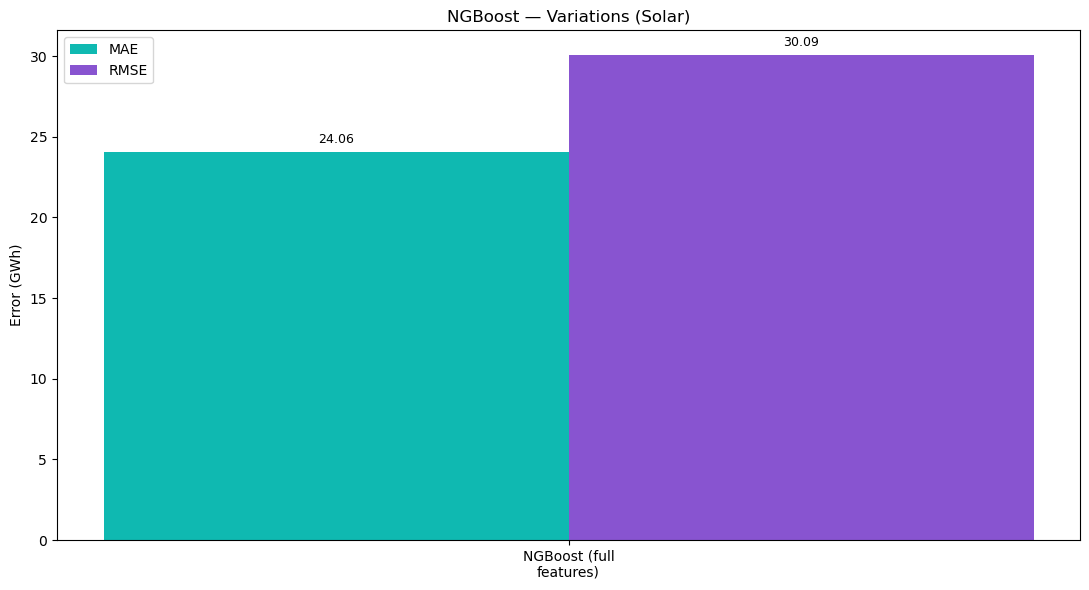

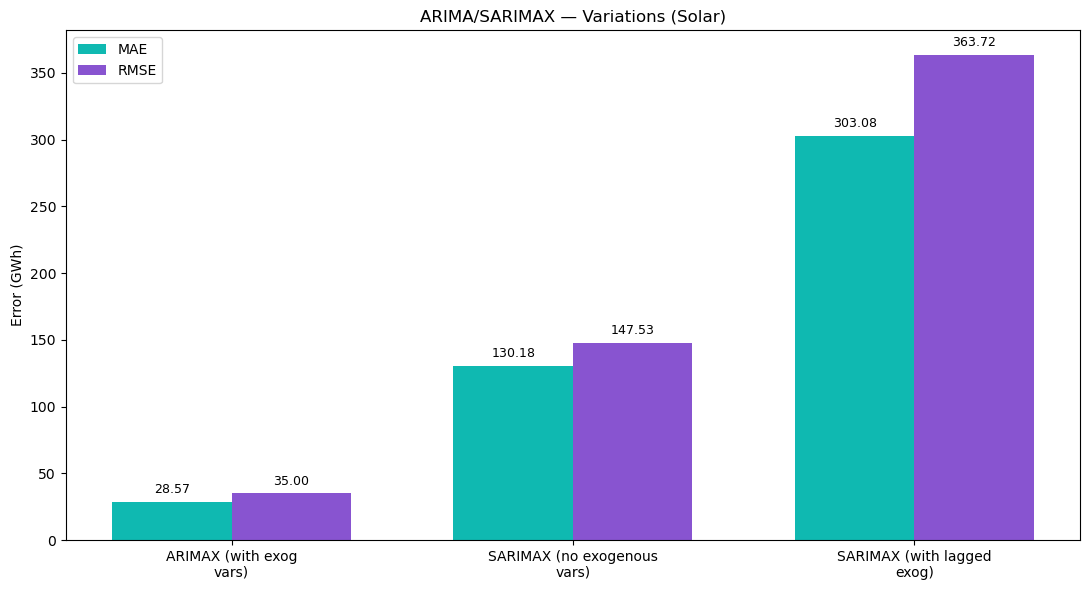

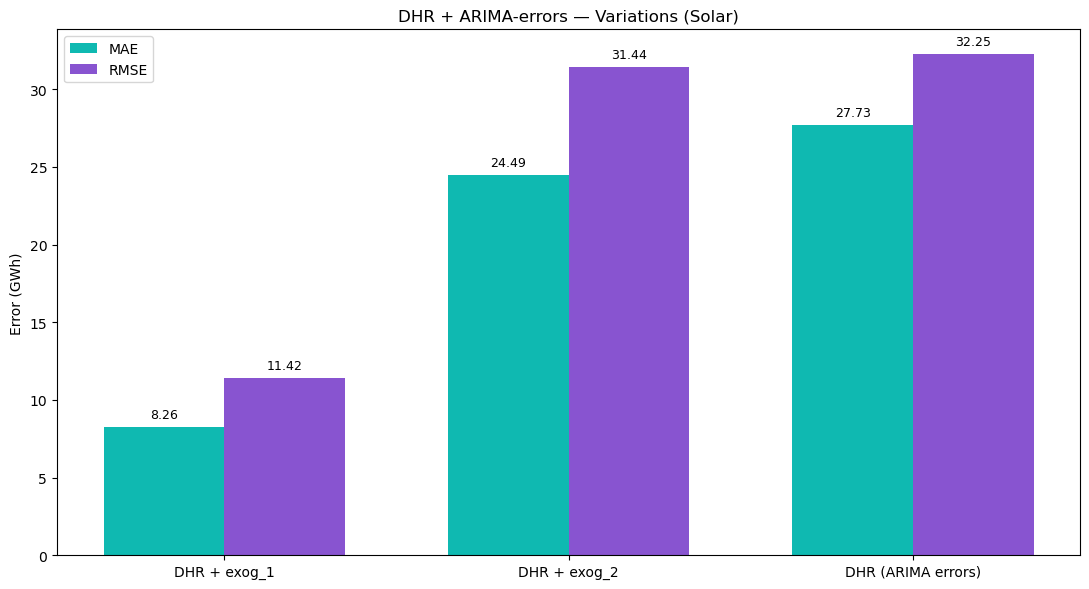

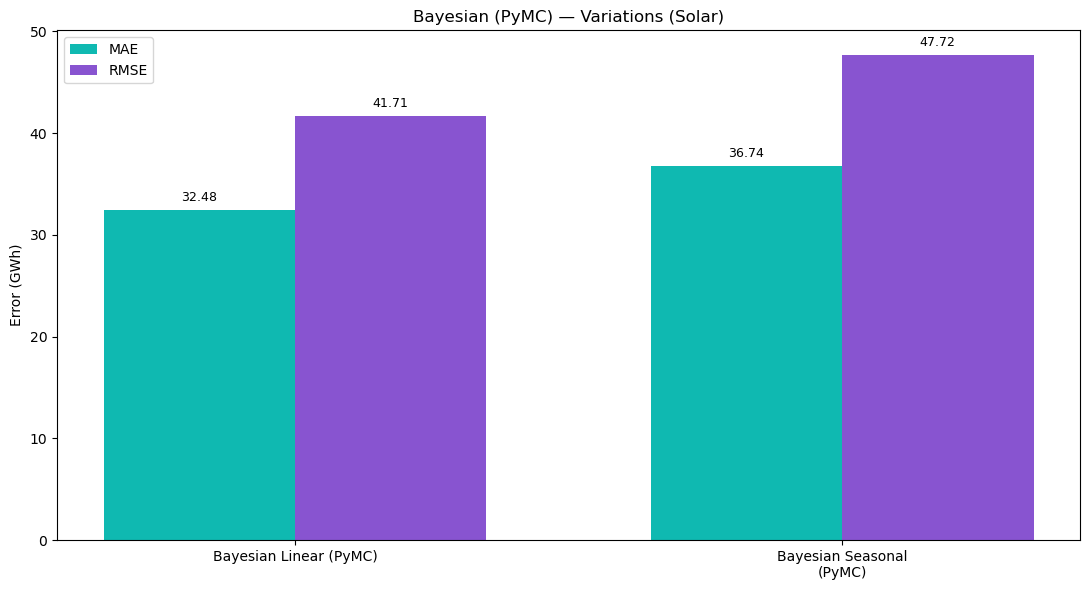

Saved winners to: C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Solar_Step1_OptionA_winners.csv
Family plots:
   NGBoost -> C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\NGBoost_Solar_variations.png
   ARIMA/SARIMAX -> C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\ARIMA_SARIMAX_Solar_variations.png
   DHR + ARIMA-errors -> C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\DHR_ARIMA-errors_Solar_variations.png
   Bayesian (PyMC) -> C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Bayesian_PyMC_Solar_variations.png


In [4]:
# Solar compariosn plot
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import re

# Paths 
LOG_CSV = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\model_logs.csv"
OUT_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison"
os.makedirs(OUT_DIR, exist_ok=True)


C_MAE  = "#0fb9b1"   
C_RMSE = "#8854d0"  

# Helpers
def wrap_labels(names, max_chars=18):
    """Wrap long labels on spaces so x-axis stays straight (no tilt)."""
    wrapped = []
    for s in names:
        parts, line, lines = s.split(), "", []
        for w in parts:
            if len(line) + len(w) + 1 <= max_chars:
                line = (line + " " + w).strip()
            else:
                lines.append(line); line = w
        if line: lines.append(line)
        wrapped.append("\n".join(lines))
    return wrapped

def safe_name(s: str) -> str:
    """Sanitize family/model name for safe file saving."""
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', s).strip('_')


def option_a_pick(group: pd.DataFrame, one_pct=0.01):
    """
    Option A selection:
    - Primary: lowest MAE
    - Tie within <=1% of lowest MAE: choose lower RMSE
    """
    g = group.copy().sort_values(["mae","rmse"])
    best_mae = g["mae"].min()
    # within 1% of best MAE
    close = g[g["mae"] <= best_mae * (1 + one_pct)]
    # among close, take lowest RMSE
    return close.sort_values("rmse").iloc[0]

def plot_family(group_df, family_name, out_dir):
    """Grouped bar chart: MAE & RMSE for variations in one family."""
    d = group_df.sort_values("mae").copy()
    x  = np.arange(len(d))
    w  = 0.35
    plt.figure(figsize=(11,6))
    b1 = plt.bar(x - w/2, d["mae"],  w, label="MAE",  color=C_MAE)
    b2 = plt.bar(x + w/2, d["rmse"], w, label="RMSE", color=C_RMSE)

    top = max(d["mae"].max(), d["rmse"].max())
    for bars in (b1, b2):
        for r in bars:
            h = r.get_height()
            plt.text(r.get_x()+r.get_width()/2, h + 0.012*top, f"{h:.2f}",
                     ha="center", va="bottom", fontsize=9)

    labels = wrap_labels(d["display_name"].tolist(), max_chars=22)
    plt.xticks(x, labels, fontsize=10)  # straight labels
    plt.ylabel("Error (GWh)")
    plt.title(f"{family_name} — Variations (Solar)")
    plt.legend()
    plt.tight_layout()

        # Use safe filename
    fpng = os.path.join(out_dir, f"{safe_name(family_name)}_Solar_variations.png")
    plt.savefig(fpng, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return fpng

# Load logs & filter Solar
logs = pd.read_csv(LOG_CSV)
solar = logs[logs["target"]=="Solar_GWh"].copy()

# make numeric
for c in ["mae","rmse","r2_score","model_size_mb","training_time_sec","inference_time_per_sample_sec"]:
    if c in solar.columns:
        solar[c] = pd.to_numeric(solar[c], errors="coerce")


def family_of(m):
    if m.startswith("NGBoost_Solar"):
        return "NGBoost"
    if m.startswith("SARIMAX_Solar") or m.startswith("ARIMAX_Solar"):
        return "ARIMA/SARIMAX"
    if m.startswith("DHR_Solar_ARIMA_errors"):
        return "DHR + ARIMA-errors"
    if m.startswith("Bayesian_"):
        return "Bayesian (PyMC)"
    return "Other"

display_map = {
    "NGBoost_Solar": "NGBoost (full features)",

    "SARIMAX_Solar_no_exog":     "SARIMAX (no exogenous vars)",
    "SARIMAX_Solar_lagged_exog": "SARIMAX (with lagged exog)",
    "ARIMAX_Solar_exog":         "ARIMAX (with exog vars)",

    "DHR_Solar_ARIMA_errors":                        "DHR (ARIMA errors)",
    "DHR_Solar_ARIMA_errors_EXOG_1":      "DHR + exog_1",
    "DHR_Solar_ARIMA_errors_EXOG_2":        "DHR + exog_2",

    "Bayesian_Seasonal_PyMC": "Bayesian Seasonal (PyMC)",
    "Bayesian_Linear_PyMC":   "Bayesian Linear (PyMC)",
}

solar["family"] = solar["model_name"].apply(family_of)
solar["display_name"] = solar["model_name"].map(display_map).fillna(solar["model_name"])

# keep only declared solar models
allowed = set(display_map.keys())
solar = solar[solar["model_name"].isin(allowed)].copy()

# pick winners per family 
plots = []
winners = []
for fam, grp in solar.groupby("family", sort=False):
    # Plot per-family grouped bars
    p = plot_family(grp, fam, OUT_DIR)
    plots.append({"family": fam, "plot_path": p})

    # winner
    w = option_a_pick(grp)
    winners.append({
        "family": fam,
        "model_name": w["model_name"],
        "display_name": w["display_name"],
        "mae": w["mae"],
        "rmse": w["rmse"],
        "r2_score": w.get("r2_score", np.nan)
    })

winners_df = pd.DataFrame(winners).sort_values("family")
winners_csv = os.path.join(OUT_DIR, "Solar_Step1_OptionA_winners.csv")
winners_df.to_csv(winners_csv, index=False)

print("Saved winners to:", winners_csv)
print("Family plots:")
for row in plots:
    print("  ", row["family"], "->", row["plot_path"])


In [ ]:
# Solar  Inter‑model comparison
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Paths 
LOG_CSV   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs\model_logs.csv"
WINNERS   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Solar_Step1_OptionA_winners.csv"
OUT_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAE  = "#0fb9b1"   # teal
C_RMSE = "#8854d0"   # purple

def wrap_labels(names, max_chars=22):
    """Wrap long labels on spaces so x-axis stays straight (no tilt)."""
    out = []
    for s in names:
        words, line, lines = s.split(), "", []
        for w in words:
            if len(line) + len(w) + 1 <= max_chars:
                line = (line + " " + w).strip()
            else:
                if line: lines.append(line)
                line = w
        if line: lines.append(line)
        out.append("\n".join(lines))
    return out

def minmax01(x):
    """0..1 normalize (handles all-equal case)."""
    s = pd.to_numeric(x, errors="coerce")
    mn, mx = s.min(), s.max()
    if np.isfinite(mn) and np.isfinite(mx) and not np.isclose(mn, mx):
        return (s - mn) / (mx - mn)
    return pd.Series(0.5, index=s.index)  # neutral if no spread

def interpretability_bonus(name: str) -> float:
    """Small bonus for models that are easy to explain in dissertation context."""
    n = (name or "").lower()
    if any(k in n for k in ["linear", "arima", "sarima", "arimax", "dhr", "tree", "extratrees", "randomforest"]):
        return 0.10
    return 0.00

# Load  winners 
logs = pd.read_csv(LOG_CSV)
solar = logs.loc[logs["target"] == "Solar_GWh"].copy()

for c in ["mae","rmse","r2_score","model_size_mb","training_time_sec","inference_time_per_sample_sec"]:
    if c in solar.columns:
        solar[c] = pd.to_numeric(solar[c], errors="coerce")

# display-name map (keeps x labels neat)
DISPLAY_MAP = {
    "NGBoost_Solar": "NGBoost (full features)",

    "ARIMAX_Solar_exog":         "ARIMAX (with exog vars)",
    "SARIMAX_Solar_no_exog":     "SARIMAX (no exogenous vars)",
    "SARIMAX_Solar_lagged_exog": "SARIMAX (with lagged exog)",

    "DHR_Solar_ARIMA_errors":                       "DHR (ARIMA errors)",
    "DHR_Solar_ARIMA_errors_EXOG_1":     "DHR + exog_1",
    "DHR_Solar_ARIMA_errors_EXOG_2":       "DHR + exog_2",

    "Bayesian_Linear_PyMC":   "Bayesian Linear (PyMC)",
    "Bayesian_Seasonal_PyMC": "Bayesian Seasonal (PyMC)",
}

if os.path.exists(WINNERS):
    w = pd.read_csv(WINNERS)
    winners_names = w["model_name"].tolist()
    df = solar[solar["model_name"].isin(winners_names)].copy()
else:
    # If winners file is missing, pick best MAE inside each family 
    def family_of(m):
        if m.startswith("NGBoost"): return "NGBoost"
        if m.startswith(("ARIMAX","SARIMAX")): return "ARIMA/SARIMAX"
        if m.startswith("DHR_Solar_ARIMA_errors"): return "DHR + ARIMA-errors"
        if m.startswith("Bayesian_"): return "Bayesian (PyMC)"
        return "Other"
    solar["family"] = solar["model_name"].apply(family_of)
    df = (solar.sort_values(["family","mae","rmse"])
                .groupby("family", as_index=False)
                .first())

# add display names
df["display_name"] = df["model_name"].map(DISPLAY_MAP).fillna(df["model_name"])

#  Build scores (higher is better)
# accuracy -> lower‑better metrics converted to 0..1 “goodness”
acc_mae  = 1 - minmax01(df["mae"])   # lower MAE = higher score
acc_rmse = 1 - minmax01(df["rmse"])  # lower RMSE = higher score

# operational smaller/faster is better
size_s  = 1 - minmax01(df["model_size_mb"])
train_s = 1 - minmax01(df["training_time_sec"])
infer_s = 1 - minmax01(df["inference_time_per_sample_sec"])
oper    = pd.concat([size_s, train_s, infer_s], axis=1).mean(axis=1)

# interpretability bonus
bonus = df["display_name"].apply(interpretability_bonus)
oper  = (oper + bonus).clip(0, 1)

# weighted final score
df["score_mae"]   = acc_mae
df["score_rmse"]  = acc_rmse
df["score_oper"]  = oper
df["final_score"] = 0.50*df["score_mae"] + 0.30*df["score_rmse"] + 0.20*df["score_oper"]

df = df.sort_values("final_score", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df)+1)

# save ranking
rank_csv = os.path.join(OUT_DIR, "Solar_Step2_ranking.csv")
df_out = df[["rank","model_name","display_name","mae","rmse","r2_score",
             "model_size_mb","training_time_sec","inference_time_per_sample_sec",
             "score_mae","score_rmse","score_oper","final_score"]]
df_out.to_csv(rank_csv, index=False)
print("Saved ranking to:", rank_csv)

#  Plot 1: Grouped MAE/RMSE (straight, wrapped x-labels)
order = df.sort_values("mae")  # show lowest MAE left-to-right
x = np.arange(len(order))
w = 0.35

plt.figure(figsize=(12,6))
b1 = plt.bar(x - w/2, order["mae"],  w, label="MAE",  color=C_MAE)
b2 = plt.bar(x + w/2, order["rmse"], w, label="RMSE", color=C_RMSE)

# annotate above bars (avoid overlap)
top = float(max(order["mae"].max(), order["rmse"].max()))
for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        plt.text(r.get_x()+r.get_width()/2, h + 0.012*top, f"{h:.2f}",
                 ha="center", va="bottom", fontsize=9)

plt.ylabel("Error (GWh)")
plt.title("Step 2: Inter-model Comparison — Solar (MAE & RMSE)")

labels_wrapped = wrap_labels(order["display_name"].tolist(), max_chars=22)
plt.xticks(x, labels_wrapped, fontsize=10)  # straight (no rotation)
plt.legend()
plt.tight_layout()
p1 = os.path.join(OUT_DIR, "Solar_Step2_grouped_MAE_RMSE.png")
plt.savefig(p1, dpi=300); plt.close()
print("Saved:", p1)


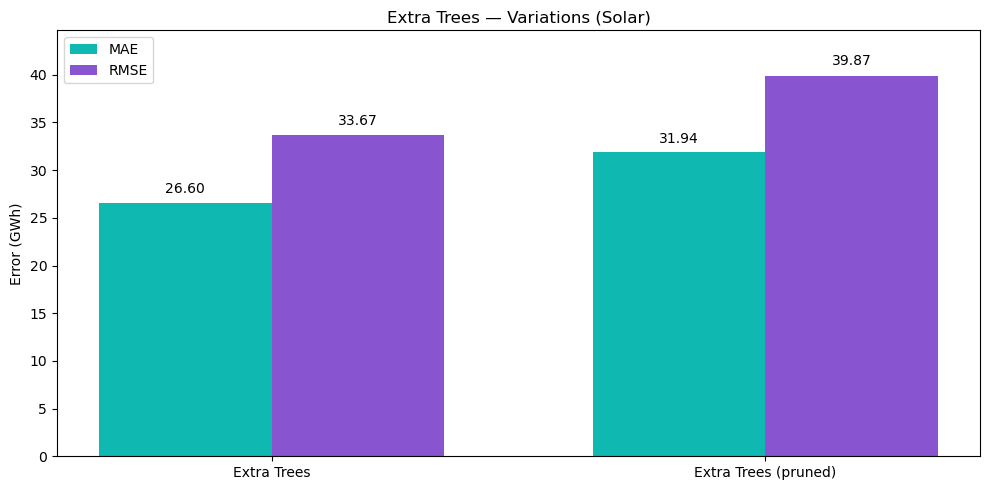

Saved: C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Extra_Trees_Solar_variations.png


In [ ]:

import os, json
import numpy as np
import matplotlib.pyplot as plt

LOG_DIR   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\logs"
FIG_PATH  = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Extra_Trees_Solar_variations.png"


FILES = [
    os.path.join(LOG_DIR, "ExtraTreesRegressor_Solar_log.json"),  
    os.path.join(LOG_DIR, "ETR_Solar_Pruned_log.json"),          
]

C_MAE  = "#0fb9b1"   # teal
C_RMSE = "#8854d0"   # purple

#  Load metrics
names, maes, rmses = [], [], []
for fp in FILES:
    with open(fp, "r") as f:
        d = json.load(f)
    name = "Extra Trees (pruned)" if "Pruned" in d.get("model_name","") or "pruned" in d.get("model_name","").lower() else "Extra Trees"
    names.append(name)
    maes.append(float(d["mae"]))
    rmses.append(float(d["rmse"]))

# Plot 
x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, maes,  width=w, color=C_MAE,  label="MAE")
b2 = ax.bar(x + w/2, rmses, width=w, color=C_RMSE, label="RMSE")

ax.set_title("Extra Trees — Variations (Solar)")
ax.set_ylabel("Error (GWh)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()

# Ensuring headroom so labels never sit on the frame
top_val = max(max(maes), max(rmses))
ax.set_ylim(0, top_val * 1.12)          
ax.margins(y=0.05)

# Add value labels with a small vertical offset
def add_labels(bars, ax, frac_offset=0.02):
    max_h = max(r.get_height() for r in bars)
    dy = max_h * frac_offset
    for r in bars:
        h = r.get_height()
        ax.text(
            r.get_x() + r.get_width()/2, h + dy,
            f"{h:.2f}",
            ha="center", va="bottom", fontsize=10,
            clip_on=False  
        )

add_labels(b1, ax, frac_offset=0.02)
add_labels(b2, ax, frac_offset=0.02)

fig.tight_layout()
os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
fig.savefig(FIG_PATH, dpi=300)
plt.show()
plt.close(fig)

print("Saved:", FIG_PATH)


In [ ]:
# Solar_Step2_grouped_MAE_RMSE_with_EXTRATREES.png

import os
import numpy as np
import matplotlib.pyplot as plt


FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison"
os.makedirs(FIG_DIR, exist_ok=True)
OUT_PATH = os.path.join(FIG_DIR, "Solar_Step2_grouped_MAE_RMSE_with_EXTRATREES.png")


models = {
    "DHR + exog_1":       (8.26, 11.42),
    "NGBoost (full\nfeatures)":        (24.06, 30.09),
    "Extra Trees\nRegressor":         (26.60, 33.67), 
    "ARIMAX (with exog\nvars)":        (28.57, 35.00),
    "Bayesian Linear\n(PyMC)":         (32.48, 41.71),
}

# Ordered labels for the x‑axis, so bars appear in this order
labels = list(models.keys())
mae_vals = [models[k][0] for k in labels]
rmse_vals = [models[k][1] for k in labels]

# plot
plt.figure(figsize=(14, 7))
x = np.arange(len(labels))
w = 0.35

C_MAE  = "#0fb9b1"  # teal
C_RMSE = "#8854d0"  # purple

mae_bars  = plt.bar(x - w/2, mae_vals,  width=w, color=C_MAE,  label="MAE")
rmse_bars = plt.bar(x + w/2, rmse_vals, width=w, color=C_RMSE, label="RMSE")

# Setting a generous top margin so value labels never collide with the top frame
ymax = max(rmse_vals + mae_vals)
plt.ylim(0, ymax * 1.15)

# Value labels 
def label_bars(bars):
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2,
                 h + ymax*0.015,  # offset
                 f"{h:.2f}",
                 ha="center", va="bottom", fontsize=10)

label_bars(mae_bars)
label_bars(rmse_bars)

plt.xticks(x, labels, rotation=0, ha="center")
plt.ylabel("Error (GWh)")
plt.title("Step 2: Inter-model Comparison — Solar (MAE & RMSE)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=300)
plt.close()

print("Saved:", OUT_PATH)


Saved: C:\Projects\GitHub\Ireland-energy-forecast\outputs\comparison_plot\Solar_comaprison\Solar_Step2_grouped_MAE_RMSE_with_EXTRATREES.png


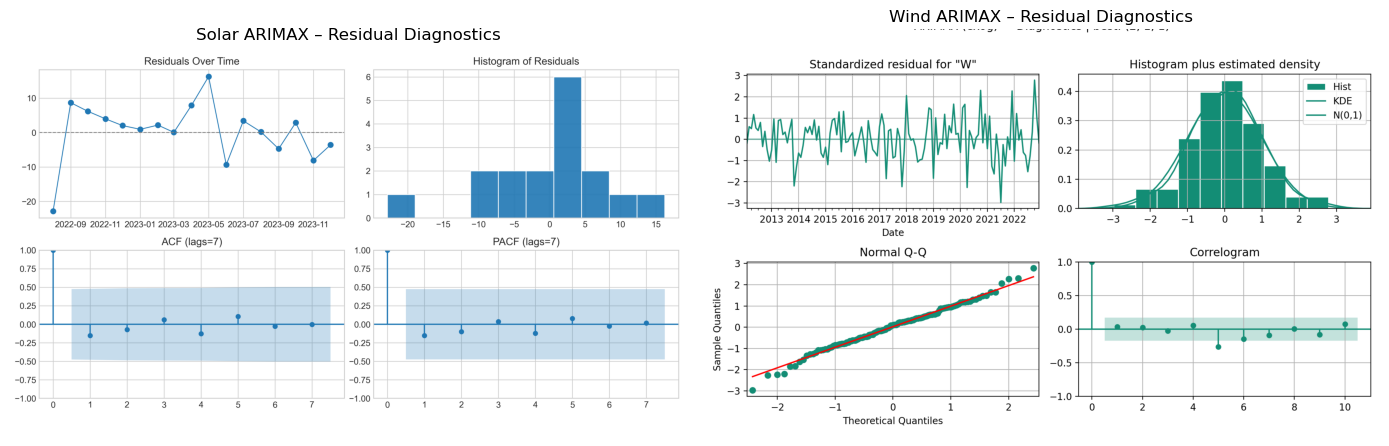

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


solar_path = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\arimax_solar_order_search_diagnostics.png"
wind_path  = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\ARiMAX_shap\order_search_arimax_exog\arimax_exog_diagnostics.png"


solar_img = mpimg.imread(solar_path)
wind_img  = mpimg.imread(wind_path)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(solar_img)
axes[0].axis("off")
axes[0].set_title("Solar ARIMAX – Residual Diagnostics")

axes[1].imshow(wind_img)
axes[1].axis("off")
axes[1].set_title("Wind ARIMAX – Residual Diagnostics")

plt.tight_layout()
plt.savefig(r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\Figure_3_6_ARIMAX_residuals_1.png", dpi=300)
plt.show()
